In [1]:
# Imports — 2-channel / 9-state stack (protocols_2ch / daq.NICardOutDual /
# experiment.run_session_2ch), replacing the old single-channel NICardOut /
# run_session flow used earlier in this notebook.

from camera import BaslerCamera
from daq import NICardOutDual, NICardIn, read_stage_voltage, read_ai_channel
from function_gen import FunctionGenerator
from protocols_2ch import SessionParams2Ch, V_CENTER
from experiment import (
    preview_particle, calibrate_trap_center, ensure_stage_at,
    run_session_2ch, run_batch_2ch, plot_session_2ch,
    build_datasync, save_session,
)
from analysis import (
    compute_potential, plot_potential,
    extract_protocol_events, lambda_trap_nm_for_state,
    compute_cumulative_work_kT, plot_x_lambda_grid, plot_work_grid, export_for_matlab,
    discover_session_files, load_session_files,
    extract_protocol_events_from_folder, extract_protocol_events_from_folders,
    load_combined_calib_pos_px,
)

import numpy as np
import matplotlib.pyplot as plt
import time


In [ ]:
import importlib
import analysis
importlib.reload(analysis)
from analysis import (
    compute_potential, plot_potential,
    extract_protocol_events, lambda_trap_nm_for_state,
    compute_cumulative_work_kT, plot_x_lambda_grid, plot_work_grid, export_for_matlab,
    discover_session_files, load_session_files,
    extract_protocol_events_from_folder, extract_protocol_events_from_folders,
)


## 1. Open camera, set ROI/exposure/gamma

Reuses the ROI/exposure/gamma already validated earlier in this notebook.

In [ ]:
exposure_us=700.0
Cam = BaslerCamera(exposure_us=exposure_us)
Cam.roi(800, 350, 250, 250)
Cam.gamma(3)


[Camera] Exposure = 600.0
[Camera] Opened
[Camera] ROI  252x250  offset (800,350)  [requested 250x250 @ (800,350)]
[Camera] Gamma = 3


In [6]:
Cam.exposure(700)
Cam.startview()

[Camera] Exposure = 700
[Camera] Preview started (particle_cross=False)


In [7]:
Cam.stopview()

[Camera] Preview stopped


In [ ]:
Cam.roi(700, 380, 400, 200)


Confirm the particle is actually visible before doing anything else — live preview at 100 fps, self-paced (press Enter in the console when you've seen it).

In [8]:
preview_particle(Cam, fps=100.0)


[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Preview started (particle_cross=True)
[Camera] Preview stopped


## 2. Open the DAQ + function generator, move the stage to 5V

`ensure_stage_at` only ramps (slowly, 10 nm/s) and waits (300s settle) if the stage isn't already at 5V — no needless wait if it's already parked there.

In [9]:
PROTOCOL_DT_S = 3.0
AO_RATE       = 1000
AI_RATE       = 3000

# AOM (laser power) voltages - see set_dc_level() and ensure_stage_at()'s
# aom_* params. TRANSIT = strong trap during physical stage moves (don't
# lose the particle in transit); EXPERIMENT = whatever's right for actual
# measurements - fill in your real value below.
AOM_TRANSIT_V    = 2.0     # near-max, used only while the stage is moving
AOM_EXPERIMENT_V = 1.0     # TODO: set to your real experiment AOM level

# Close any ao/ai/funcgen/aom_gen already open from a previous run of this
# cell before creating new ones - otherwise the old NICardOutDual's two
# nidaqmx Tasks (AO + DO) never get closed, and Python garbage-collecting
# them later prints a DaqResourceWarning ("Task ... was not explicitly
# closed") - or worse, a real "device busy" error if you reopen the same
# channels before the old ones are released.
for _name in ("ao", "ai", "funcgen", "aom_gen"):
    if _name in globals():
        try:
            globals()[_name].close()
        except Exception:
            pass

ao      = NICardOutDual(n_samples=int(PROTOCOL_DT_S * AO_RATE), rate=AO_RATE)
ai      = NICardIn(rate=AI_RATE)
funcgen = FunctionGenerator()   # camera-trigger generator 
aom_gen = FunctionGenerator(usb_id="USB0::0x0699::0x0358::C020332::INSTR")  # AOM/laser-power generator 

Cam.hardwareTrigg()
#ensure_stage_at(ao, V_CENTER, speed_nm_per_s=200.0, camera=Cam, live_preview=True, settle_s = 0.5)


[Camera] Hardware trigger (Line2, rising edge)


In [19]:
AOM_EXPERIMENT_V = 1.0
aom_gen.set_dc_level(AOM_EXPERIMENT_V)

In [11]:
# Internal diagnostic/plotting helpers used by sections 3c/9/10 below (latency
# stats, calibration sweeps, ai1-vs-ai3 comparison, the 3c fire-session plot) -
# moved out of this notebook into helper.py to keep it short. See helper.py's
# own docstring for why `import *` still works despite the leading-underscore names.
from helper import *


In [12]:
ensure_stage_at(ao, V_CENTER, speed_nm_per_s=100.0, camera=Cam, live_preview=True, settle_s = 300,
                aom_gen=aom_gen, aom_transit_v=AOM_TRANSIT_V, aom_experiment_v=AOM_EXPERIMENT_V)


Stage already at 4.980 V (target 5.000 V) - no move needed.


4.97961772742914

In [13]:
v_adder  = read_ai_channel("AdderOut")   # ai3 — commanded ao0/10+ao1
v_stage  = read_ai_channel("Stage")      # ai1 — same as read_stage_voltage()
v_camout = read_ai_channel("CamOut")     # ai2 — camera trigger confirmation line
v_aom    = read_ai_channel("AOM")        # ai0

print("v_adder  = ", v_adder)
print("v_stage  = ", v_stage)

v_adder  =  4.997774414142477
v_stage  =  4.979596765002206


In [ ]:
ao.set_dc(ao0_v=0, ao1_v=0)


## 3. Calibrate the trap center

Run once (or whenever you want to recheck) with the particle resting undisturbed. The camera stays open afterward — unlike the earlier exploratory cells in this notebook, we need it for everything below.

In [25]:
import os

CALIB_FOLDER = r"D:\data\calib04"   # folder to hold this batch's calibration runs
N_CALIB      = 1                    # how many calibrate_trap_center() runs
os.makedirs(CALIB_FOLDER, exist_ok=True)

calib_runs = []   # [(x_center_nm, y_center_nm, calib_pos_px), ...] - every run, in memory too
for i in range(1, N_CALIB + 1):
    x_center_nm, y_center_nm, calib_pos_px = calibrate_trap_center(
        Cam, duration_s=3600.0, fps=100.0,
        savepath=os.path.join(CALIB_FOLDER, f"calib{i+1}"),   # -> CALIB_FOLDER/calib{i}_calib_pos_px.npy
    )
    print(f"Run {i}/{N_CALIB}: x_center_nm={x_center_nm:+.1f} nm  y_center_nm={y_center_nm:+.1f} nm")
    calib_runs.append((x_center_nm, y_center_nm, calib_pos_px))

# x_center_nm/y_center_nm above are the LAST run's values (still feed the
# pinning cell right below unchanged) - calib_runs holds every run's own
# (x_center_nm, y_center_nm, calib_pos_px) if you want to compare/average
# across the N runs before picking what to pin.
#
# calib_pos_px columns: [x_px, y_px, time_s] — one row per frame, NaN where
# a frame was dropped or the particle wasn't found. Multiply calib_pos_px[:, :2]
# by your own nm_per_px if/when you want it in nm instead of pixels.


[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Started
[Camera] Stopped
Trap center: x=+1801.1 nm  y=+1876.7 nm  (360000/360000 frames had a valid reading)
Saved: D:\data\calib04\calib2_calib_pos_px.npy
Run 1/1: x_center_nm=+1801.1 nm  y_center_nm=+1876.7 nm


In [29]:
from camera import NM_PER_PX

combined_calib_px = load_combined_calib_pos_px(CALIB_FOLDER)   # every *_calib_pos_px.npy in CALIB_FOLDER, pooled
valid = ~np.isnan(combined_calib_px[:, 0])
x_center_nm = float(np.mean(combined_calib_px[valid, 0])) * NM_PER_PX
y_center_nm = float(np.mean(combined_calib_px[valid, 1])) * NM_PER_PX
print(f"Combined trap center over {valid.sum()}/{len(combined_calib_px)} valid frames "
      f"(pooled across every calib run saved in {CALIB_FOLDER}):")
print(f"  x_center_nm = {x_center_nm:+.2f} nm   y_center_nm = {y_center_nm:+.2f} nm")

# To pin a hand-picked value instead of the combined-file estimate above,
# just reassign below, e.g.:
# x_center_nm = 1594.38
# y_center_nm = 2086


Combined trap center over 360000/360000 valid frames (pooled across every calib run saved in D:\data\calib04):
  x_center_nm = +1801.09 nm   y_center_nm = +1876.71 nm


In [22]:
x_center_nm = 1798.23
y_center_nm = 1875.27

0/360000 frames dropped or not found (0.0%)


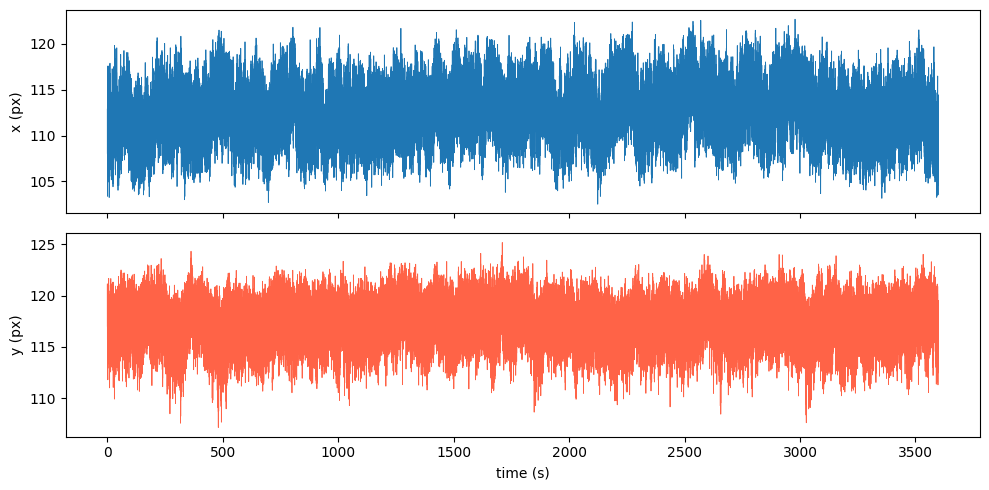

In [30]:
# Quick look at tracking quality — raw pixels, not nm — gaps = dropped
# frames or lost particle.
n_dropped = int(np.isnan(calib_pos_px[:, 0]).sum())
print(f"{n_dropped}/{len(calib_pos_px)} frames dropped or not found "
      f"({n_dropped/len(calib_pos_px):.1%})")

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(calib_pos_px[:, 2], calib_pos_px[:, 0], lw=0.6)
axes[0].set_ylabel("x (px)")
axes[1].plot(calib_pos_px[:, 2], calib_pos_px[:, 1], lw=0.6, color="tomato")
axes[1].set_ylabel("y (px)")
axes[1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()


k_fit = 2.9514e-06 N/m   k_eq = 2.4326e-06 N/m   (T = 298 K)


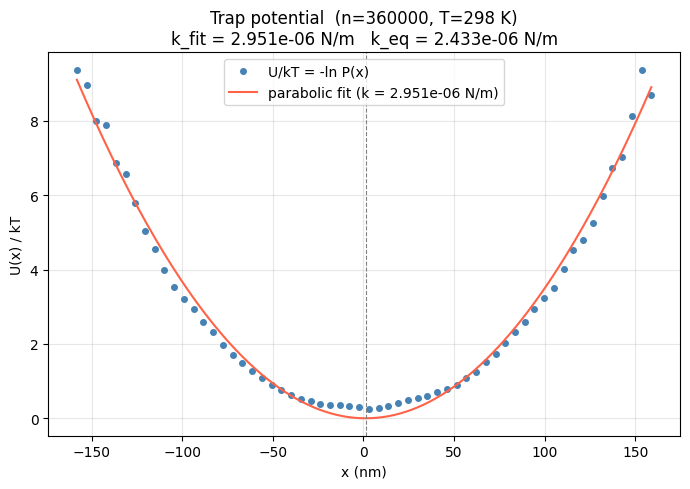

In [31]:
from camera import NM_PER_PX

# Uses the SAME combined, pooled data (combined_calib_px, from the cell
# above) for both x_center_nm and the potential itself - previously this
# mixed calib_pos_px (only the LAST calibrate_trap_center() run still in
# memory) with whatever x_center_nm happened to be pinned, which didn't
# have to come from the same data at all.
x_nm_equilibrium = combined_calib_px[:, 0] * NM_PER_PX - x_center_nm

potential_result = compute_potential(x_nm_equilibrium, n_bins=60, T_K=298.0)
print(f"k_fit = {potential_result['k_fit_N_per_m']:.4e} N/m   "
      f"k_eq = {potential_result['k_eq_N_per_m']:.4e} N/m   "
      f"(T = {potential_result['T_K']:.0f} K)")

plot_potential(potential_result)


## 3b. Analytical-protocol-consistent decode threshold

`xth_nm` must match whatever `x_thresh_sigma_multiple`/`kappa`/`T` the
saved analytical protocol files (section 3c) were actually computed
with — using the same formula `sdesim.params.SystemVariables.create()`
uses (`x_thresh = sqrt(k_B*T/kappa) * x_thresh_sigma_multiple`, confirmed
directly against that source), reproduced here rather than imported since
`analytical_optimal_protocol_computation` lives in its own venv
(scipy/numba) — see `analytical_protocols.py`'s docstring. Fill in the
three constants below to match your actual run; everywhere downstream
(sections 4, 5, 6) uses this same `xth_nm`, not an independent guess.

Also computes `xth_nm_single`, the same formula for the single-measurement
(`delta_t_s=0`) case — its own constants, since the `t2_0_...` files (section
3c) were generated with a different `x_thresh_sigma_multiple`/`kappa` than
the `t2_1_...` (two-measurement) ones.

In [32]:
from analysis import K_BOLTZMANN_J_PER_K

# TODO: must match the SystemVariables the saved analytical protocol files
# (section 3c's ANALYTICAL_SAVE_DIR/ANALYTICAL_T2/ANALYTICAL_TF) were
# actually generated with.
ANALYTICAL_KAPPA_N_PER_M       = 2.9e-6   # trap stiffness (N/m)
ANALYTICAL_T_K                 = 298.0  # temperature (K)
ANALYTICAL_X_THRESH_SIGMA_MULT = 1    # threshold, in multiples of sigma

sigma_nm = np.sqrt(K_BOLTZMANN_J_PER_K * ANALYTICAL_T_K / ANALYTICAL_KAPPA_N_PER_M) * 1e9
xth_nm   = ANALYTICAL_X_THRESH_SIGMA_MULT * sigma_nm
print(f"sigma = {sigma_nm:.2f} nm   xth_nm = {ANALYTICAL_X_THRESH_SIGMA_MULT} * sigma = {xth_nm:.2f} nm")

# Single-measurement (delta_t=0) case - see run_session_2ch's docstring.
# Own constants: the t2_0_... files (section 3c) were generated with a
# different x_thresh_sigma_multiple/kappa than the t2_1_... (two-
# measurement) ones - check the .csv alongside the .npz files in
# ANALYTICAL_SAVE_DIR for the exact values actually used.
ANALYTICAL_KAPPA_N_PER_M_SINGLE       = 2.5e-6   # trap stiffness (N/m)
ANALYTICAL_T_K_SINGLE                 = 298.0    # temperature (K)
ANALYTICAL_X_THRESH_SIGMA_MULT_SINGLE = 1.0      # threshold, in multiples of sigma

sigma_nm_single = np.sqrt(K_BOLTZMANN_J_PER_K * ANALYTICAL_T_K_SINGLE / ANALYTICAL_KAPPA_N_PER_M_SINGLE) * 1e9
xth_nm_single   = ANALYTICAL_X_THRESH_SIGMA_MULT_SINGLE * sigma_nm_single
print(f"sigma_single = {sigma_nm_single:.2f} nm   xth_nm_single = {ANALYTICAL_X_THRESH_SIGMA_MULT_SINGLE} * sigma_single = {xth_nm_single:.2f} nm")


sigma = 37.67 nm   xth_nm = 1 * sigma = 37.67 nm
sigma_single = 40.57 nm   xth_nm_single = 1.0 * sigma_single = 40.57 nm


## 3c. Load real analytical protocols

Loads the actual optimal λ(t) shapes computed by `analytical_optimal_protocol_computation/scripts/run_single_parameter_point.py` (replacing `protocols_2ch.BASE_PROTOCOLS`'s placeholders) via `analytical_protocols.load_analytical_protocols()` — resamples each `(m_0, m_t)` state onto the AO grid and applies the trap→stage sign negation (see `EXPERIMENT_ARCHITECTURE.md`, "Analytical protocols"). Prints which of the 9 states loaded (sanity check that this points at the right saved sweep point), then plots a 3×3 grid (one panel per `(m_0, m_t)`) — same layout/style as `analytical_optimal_protocol_computation`'s own `plot_optimal_trajectories_grid`, so directly comparable to those reference plots, but showing the stage-frame command actually sent to hardware (post sign-negation) rather than the trap-frame `X`/`X_b`/`λ`.

`ANALYTICAL_T2`/`ANALYTICAL_TF` must match whatever `run_single_parameter_point.py` was actually run with — a mismatch raises `FileNotFoundError`, not a silent wrong answer. The resulting `analytical_protocols` dict is what sections 4/5/6 below pass into `run_session_2ch(..., protocols=analytical_protocols)`/`run_batch_2ch(..., protocols=analytical_protocols)` to actually fire these real shapes instead of the placeholders — this cell just loads it once; it stays in memory for everything below (no per-fire reload). Re-run just this cell whenever you regenerate/update the saved protocol files — the manual keyboard fire test in 3d is optional and separate, no need to re-run it every time.

Also loads `analytical_protocols_single`, the same idea for `t_second_measurement=0` (single-measurement, `delta_t_s=0` sessions — see `run_session_2ch`'s docstring) — same folder, only the diagonal states `(1,1)`/`(-1,-1)`/`(0,0)` are ever meaningful, since `decode_state_pair(x, x, xth_nm)` can never produce an off-diagonal state. Reuse section 5's/6's cells as-is for an actual single-measurement session, just swapping in `delta_t_s=0.0`, `xth_nm=xth_nm_single`, and `protocols=analytical_protocols_single`.

Loaded 9/9 states: [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]
Key -> state:
  0: (1, 1)  (loaded)
  1: (1, 0)  (loaded)
  2: (0, 1)  (loaded)
  3: (-1, 1)  (loaded)
  4: (-1, -1)  (loaded)
  5: (-1, 0)  (loaded)
  6: (0, -1)  (loaded)
  7: (1, -1)  (loaded)
  8: (0, 0)  (loaded)


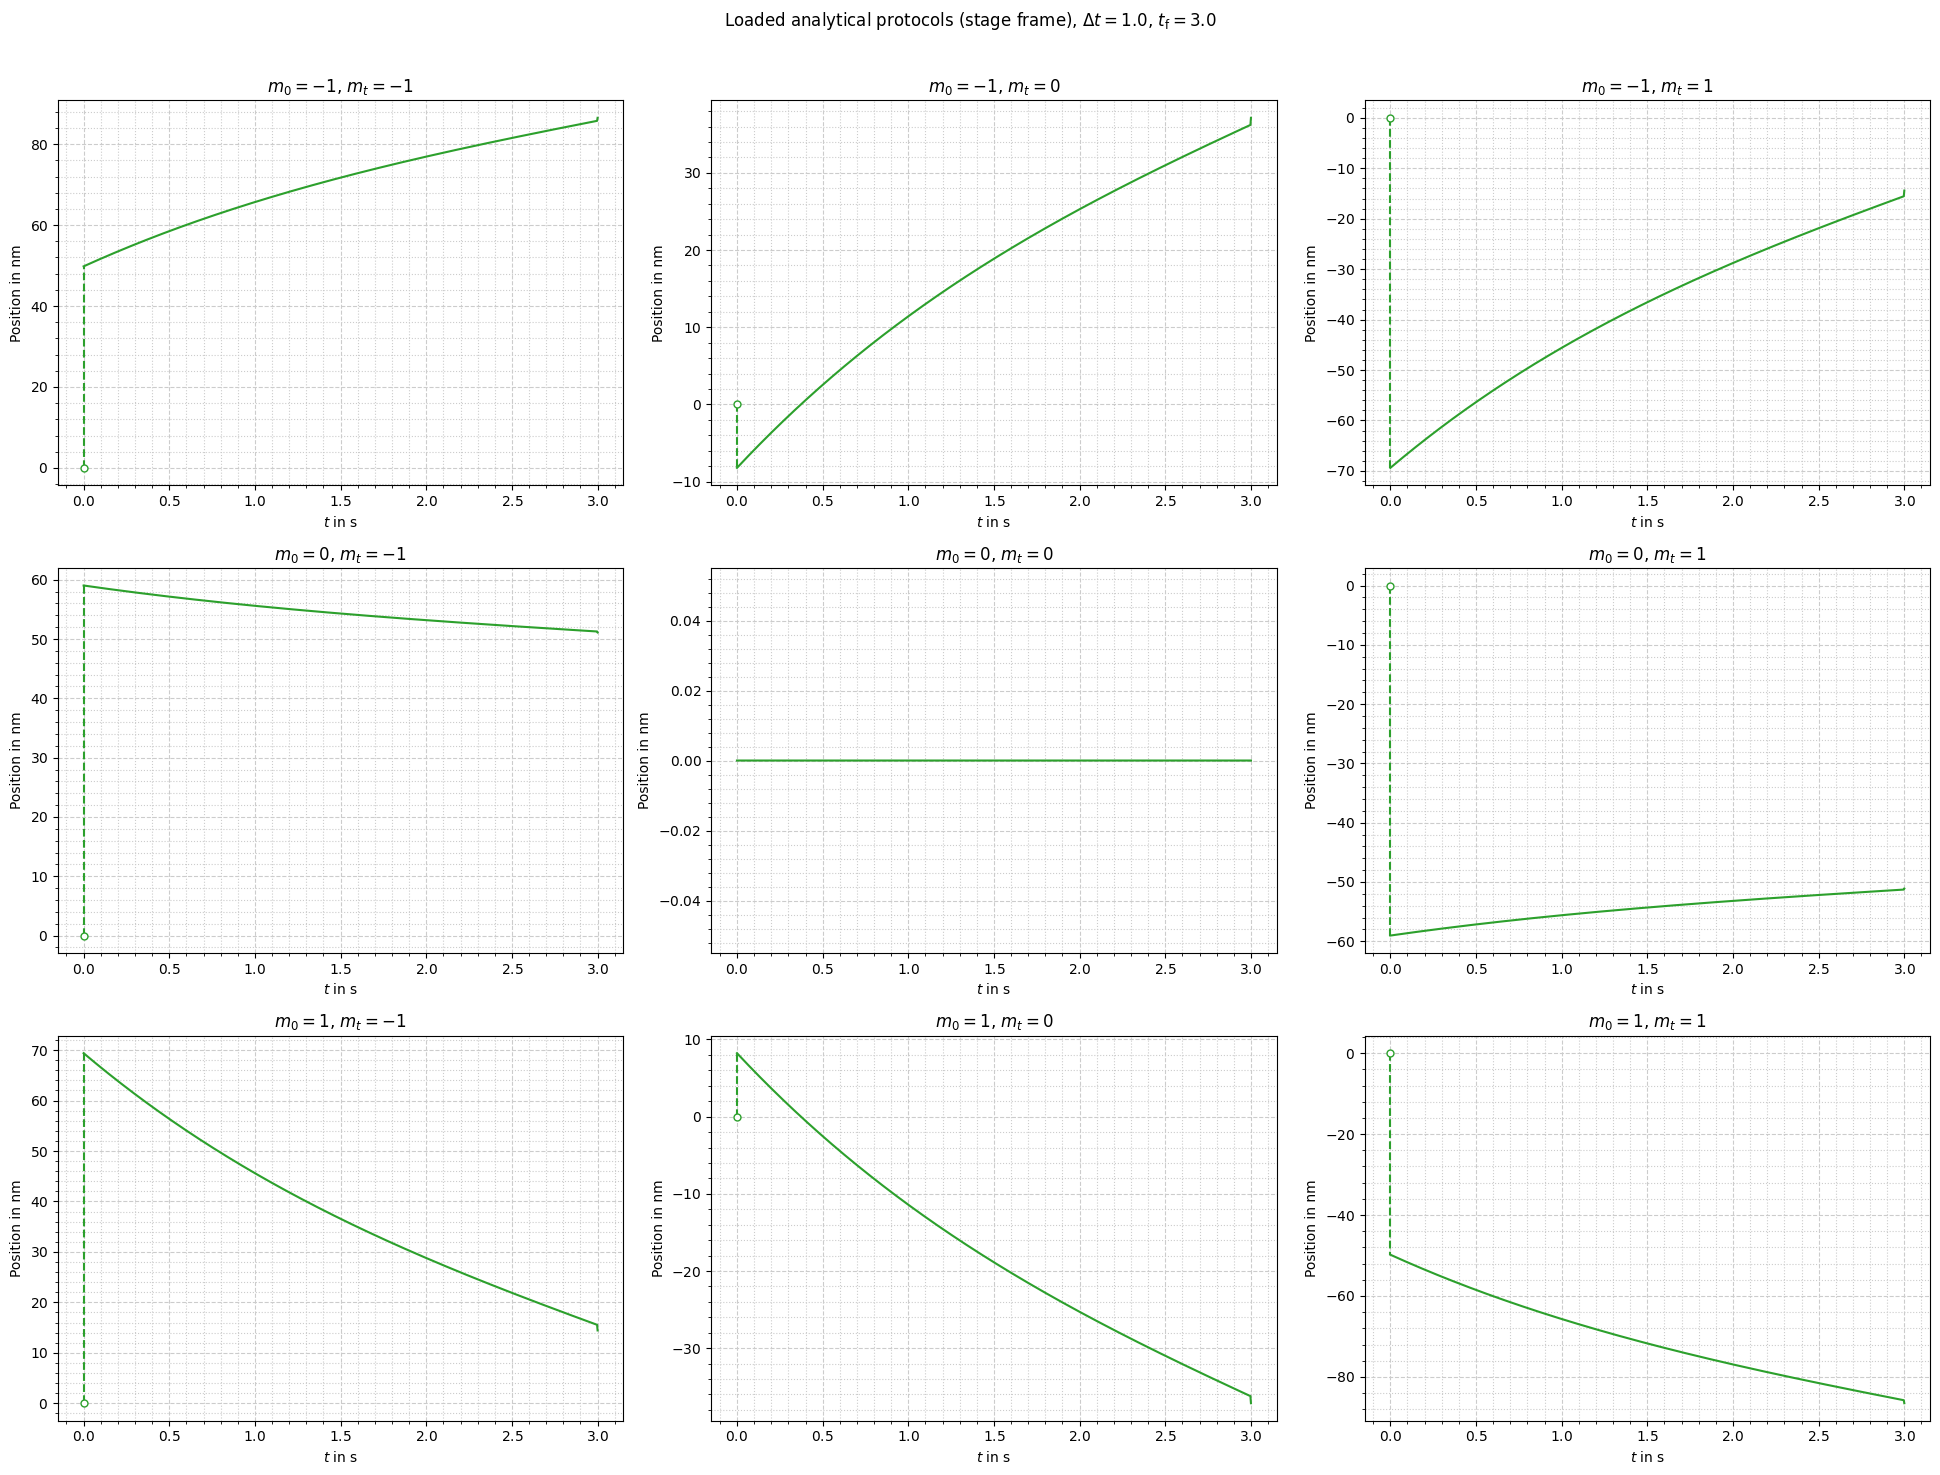

Loaded 3/3 states: [(-1, -1), (0, 0), (1, 1)]


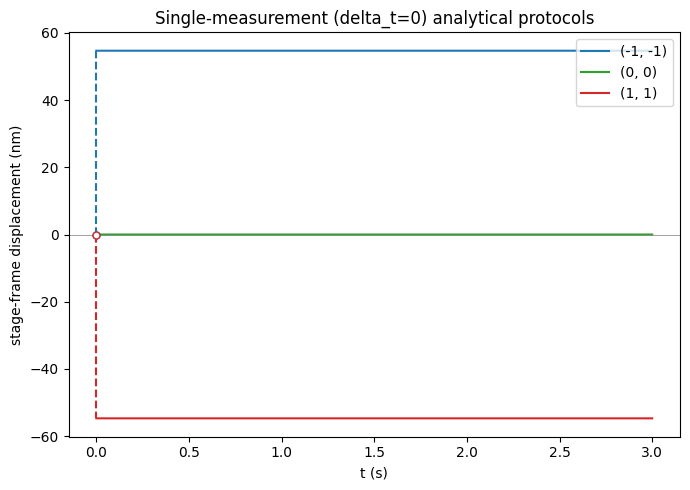

In [33]:
from analytical_protocols import load_analytical_protocols
from protocols_2ch import STATE_MENU

ANALYTICAL_SAVE_DIR = r"analytical_optimal_protocol_computation/parameters/optimal_protocols_multiple_measurement"
ANALYTICAL_T2  = 1.0            # must match t_second_measurement the files were generated with
ANALYTICAL_TF  = PROTOCOL_DT_S  # must match t_protocol_end the files were generated with

# ao was constructed with n_samples=int(PROTOCOL_DT_S * AO_RATE) (cell 9) -
# load_analytical_protocols resamples every state onto int(ANALYTICAL_TF *
# AO_RATE) samples, so these two must agree or split_channels() hands
# ao.load() a wrongly-sized array. A FINITE AO task silently truncates a
# too-long waveform rather than erroring (see hw_two_channel_test.py's
# notes), so this is worth catching loudly instead.
assert ANALYTICAL_TF == PROTOCOL_DT_S, (
    f"ANALYTICAL_TF ({ANALYTICAL_TF}) must equal PROTOCOL_DT_S "
    f"({PROTOCOL_DT_S}) - ao was built for the latter."
)

analytical_protocols = load_analytical_protocols(
    ANALYTICAL_SAVE_DIR, ANALYTICAL_T2, ANALYTICAL_TF, ao_rate=AO_RATE,
)
print(f"Loaded {len(analytical_protocols)}/9 states: {sorted(analytical_protocols)}")

print("Key -> state:")
for key, state in STATE_MENU.items():
    print(f"  {key}: {state}" + ("  (loaded)" if state in analytical_protocols else "  (NOT loaded)"))

# 3x3 grid, one subplot per (m_0, m_t) combination - same layout/style as
# analytical_optimal_protocol_computation's own
# visualization.py::plot_optimal_trajectories_grid(n_outcomes=3), so this
# is directly comparable to those reference plots. Only one line per panel
# here (the stage-frame command actually sent to ao0/ao1, after the
# trap->stage sign negation) rather than X/Xb/lambda, since that's all
# load_analytical_protocols() carries forward.
from matplotlib.ticker import AutoMinorLocator


def _plot_lambda_jump(ax, value0, color):
    """
    Mirrors visualization.py::_plot_lambda_jump - the trap (and so, after
    negation, the stage) sits at rest (0) right up to t=0, then jumps to
    the first commanded sample: a dashed vertical segment from (0, 0) to
    (0, value0), plus a small open circle marking the pre-jump rest point.
    No-op when the first sample already is 0 (e.g. the (0,0) no-op state).
    """
    if value0 == 0:
        return
    ax.plot([0, 0], [0, value0], color=color, linestyle="--", lw=1.5)
    ax.plot(0, 0, marker="o", ms=5, mfc="white", mec=color, zorder=5)


t_ao_plot = np.linspace(0.0, ANALYTICAL_TF, int(ANALYTICAL_TF * AO_RATE))
labels = [-1, 0, 1]
combinations = [(m_0, m_t) for m_0 in labels for m_t in labels]

fig = plt.figure(figsize=(6.5 * 3, 5 * 3))
for index, state in enumerate(combinations):
    ax = fig.add_subplot(3, 3, index + 1)
    ax.grid(which='major', color='#CCCCCC', linestyle='--')
    ax.grid(which='minor', color='#CCCCCC', linestyle=':')
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 3), useMathText=True)
    ax.set_xlabel("$t$ in s")
    ax.set_ylabel("Position in nm")
    ax.set_title(f"$m_0={state[0]}$, $m_t={state[1]}$")

    if state not in analytical_protocols:
        ax.text(0.5, 0.5, "no data", ha='center', va='center', transform=ax.transAxes)
        continue

    wave = analytical_protocols[state]
    line, = ax.plot(t_ao_plot, wave, color="tab:green")
    _plot_lambda_jump(ax, wave[0], line.get_color())

fig.suptitle(
    f"Loaded analytical protocols (stage frame), "
    f"$\\Delta t={ANALYTICAL_T2}$, $t_{{\\mathrm{{f}}}}={ANALYTICAL_TF}$"
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Single-measurement (delta_t=0) protocols - same folder, t_second_measurement=0.
# Only the diagonal states are ever meaningful (see SINGLE_MEASUREMENT_STATES's
# docstring in analytical_protocols.py) - decode_state_pair(x, x, xth_nm) can
# never produce an off-diagonal state, so real_states=SINGLE_MEASUREMENT_STATES
# avoids a spurious "missing" warning about the 6 states that were never
# expected to have files at all.
from analytical_protocols import SINGLE_MEASUREMENT_STATES

analytical_protocols_single = load_analytical_protocols(
    ANALYTICAL_SAVE_DIR, t_second_measurement=0, t_protocol_end=PROTOCOL_DT_S, ao_rate=AO_RATE,
    real_states=SINGLE_MEASUREMENT_STATES,
)
print(f"Loaded {len(analytical_protocols_single)}/3 states: {sorted(analytical_protocols_single)}")

fig, ax = plt.subplots(figsize=(7, 5))
for state in sorted(analytical_protocols_single):
    wave = analytical_protocols_single[state]
    line, = ax.plot(t_ao_plot, wave, label=str(state))
    _plot_lambda_jump(ax, wave[0], line.get_color())
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("t (s)")
ax.set_ylabel("stage-frame displacement (nm)")
ax.set_title("Single-measurement (delta_t=0) analytical protocols")
ax.legend()
plt.tight_layout()
plt.show()



## 3d. Manual keyboard fire test (ao0) — optional

Optional sanity check, kept separate from 3c so you don't have to run a keyboard-driven fire session every time you regenerate/reload `analytical_protocols` above — just re-run 3c alone when the saved protocol files change, and only re-run this cell when you actually want to physically exercise the shapes. Fires the real loaded shape for a chosen state on `ao0` (with the usual `ao1` handoff) from a keyboard loop. Purely manual — no camera decode involved here.

`ai1` (Stage) and `ai3` (AdderOut) are recorded continuously for the whole keyboard session (same `ai.start_continuous()`/`stop_and_get()` pattern as everywhere else in this notebook); on `q`, `helper.plot_fire_session()` plots both real channels together with each fire shaded and labeled — same segmented-overlay idea as `hw_two_channel_test.py`'s `plot_session()`, extended to compare the two real channels against each other (this notebook's established `ai1`-vs-`ai3` pattern) instead of one channel against a value predicted from the waveform's formula.

Requires `analytical_protocols` to already be loaded (3c above).

In [ ]:
from protocols_2ch import split_channels, STATE_MENU

# Start from wherever ao1 actually is right now (read the real commanded
# node, ai3/AdderOut - same "seed from ai3, not ai1" rule as every other
# cell in this notebook) rather than assuming V_CENTER - this is a quick
# fire test, not a real session, so it shouldn't force a slow ramp back to
# center first if the stage is already resting somewhere else.
ao1_offset0 = read_ai_channel("AdderOut")

ai.start_continuous()
_wait_for_ai_sample_count(ai)   # see its docstring — a fixed short sleep
                                # here reads a stale/zero sample count and
                                # mislabels the whole plot's time axis
ai_idx0 = ai.get_sample_count()
t0 = time.perf_counter()

ao1_offset = [ao1_offset0]   # persists across fires, same handoff convention as protocols_2ch/hw_two_channel_test.py
fire_segments, fire_labels = [], []
try:
    while True:
        raw = input("State (0-8, q to stop) > ").strip().lower()
        if raw == 'q':
            break
        if raw not in STATE_MENU:
            print("  Enter 0-8 (see menu above) or 'q'.")
            continue
        state = STATE_MENU[raw]
        if state not in analytical_protocols:
            print(f"  No analytical protocol loaded for {state} — skipping.")
            continue

        # (0,0)'s waveform is exact zeros, so firing it is just a plain hold -
        # no special-casing needed the way hw_two_channel_test.py has one.
        ao0_wave, ao1_wave, ao1_new = split_channels(analytical_protocols[state], ao1_offset[0])
        idx_start = int((time.perf_counter() - t0) * ai.rate)
        ao.load(ao0_wave, ao1_wave)
        ao.start()
        ao.wait_done(extra_s=PROTOCOL_DT_S + 5.0)
        ao1_offset[0] = ao1_new

        fire_segments.append((idx_start, len(ao0_wave)))
        fire_labels.append(str(state))   # plain (m_0,m_t) - not STATE_LABELS'
                                          # "mirror"/shape-name text, which
                                          # describes the PLACEHOLDER
                                          # generation method, not this one
                                          # (every state here is loaded
                                          # independently, none is derived
                                          # from another at fire time)
        print(f"  Fired {state} — ao1 offset now {ao1_offset[0]:.4f} V")
finally:
    # Guarantees ai1/ai3 are released even on interrupt — same discipline
    # as every other ai.start_continuous() use in this notebook.
    fire_ai_data = ai.stop_and_get()

if fire_segments:
    plot_fire_session(fire_ai_data, ai.channel_names, ai.rate, ai_idx0,
                      fire_segments, fire_labels, baseline_v=ao1_offset0,
                      title="3d: analytical protocol keyboard-fire session")
else:
    print("No protocols fired — nothing to plot.")


## 4. Characterize the trap: equilibrium recording → potential + stiffness

`active_states=set()` — the real 9-state decode runs the whole time (you'll see it in the console log), but nothing ever fires, so `pos[:,1]` is pure thermal motion in the trap. Feed it to `compute_potential`/`plot_potential` (kT units) to see the potential shape and get the stiffness two ways (parabolic fit vs. equipartition) as a cross-check.

In [ ]:
equilibrium_params = SessionParams2Ch(
    trecord_s     = 600.0,     # short characterization run
    fps           = 100.0,
    exposure_us   = exposure_us,
    x_center_nm   = x_center_nm,
    y_center_nm   = y_center_nm,
    protocol_dt_s = PROTOCOL_DT_S,
    ai_rate       = AI_RATE,
    ao_rate       = AO_RATE,
    print_every   = 10,       # equilibrium checkpoints are frequent — throttle the log
    print_no_fire = True,     # active_states=set() below means EVERY checkpoint
                              # is a no-fire - without this the run prints
                              # nothing at all (print_no_fire now defaults to
                              # False), the one case the docstring calls out
    xth_nm        = xth_nm,   # from cell 2b — doesn't affect this run's physics
                              # (active_states=set() never fires), but keeps
                              # the console-logged decoded state consistent
                              # with every other cell in this notebook
)

equilibrium_result = run_session_2ch(
    equilibrium_params, ao, ai, Cam, funcgen,
    ao1_start_v=V_CENTER, active_states=set(), live_preview=True,
    protocols=analytical_protocols,  # from 3c — harmless here (active_states=set()
                                      # means nothing ever fires), kept for consistency
)


In [ ]:
x_nm_equilibrium = equilibrium_result["pos"][:, 1]

potential_result = compute_potential(x_nm_equilibrium, n_bins=60, T_K=298.0)
print(f"k_fit = {potential_result['k_fit_N_per_m']:.4e} N/m   "
      f"k_eq = {potential_result['k_eq_N_per_m']:.4e} N/m   "
      f"(T = {potential_result['T_K']:.0f} K)")

plot_potential(potential_result)


## 5. Check protocols against the real particle

`states_to_check` — the real decode still runs on the whole trajectory; a protocol only fires when the decoded state is one of these (not forced/periodic), so the statistics stay valid for a later work/thermodynamics calculation. `run_session_2ch` already accepts a multi-state `active_states` set directly, so checking several states in one run (e.g. a mirror pair like `{(1,1), (-1,-1)}`) needs no code change. Change the set below and re-run to check a different combination. `plot_session_2ch` shows the fired shapes against the real `ai3` trace and the particle's actual response.

`T_WAIT_S` sets the post-fire equilibration wait (`T_relax_s`) so the next measurement starts from equilibrium, not mid-relaxation. `CHECK_SAVEPATH` + the `save_session(...)` call at the end persist `pos`/`DataSync`/`ai_data`/`params` (+ `active_states`/`protocols_loaded`) for this run — see section 5b below for the per-state event/work analysis built on top of this.

In [ ]:
states_to_check = {(1, 1), (-1, -1)}   # edit and re-run for any combination

T_WAIT_S       = 100.0    # equilibration wait AFTER the fired protocol
                          # finishes (protocol_dt_s), before the next decide
                          # checkpoint - additive, not overlapping: the total
                          # gap after a fire is protocol_dt_s + T_WAIT_S.
                          # Applied via T_relax_s (protocols_2ch.py's own
                          # name for exactly this wait).
CHECK_SAVEPATH = r"D:\data\check01"   # path prefix for this run's saved
                                      # pos/DataSync/ai_data/params files
FIRE_00_PROB   = 1.0 / 100.0    # unbiased Bernoulli draw each time (0,0) is
                                # decoded - fires its flat/zero protocol
                                # roughly 1-in-100 times, for null-work stats
                                # without spending too much time on it


check_params = SessionParams2Ch(
    trecord_s     = 3600.0,    # long enough to see several natural occurrences
    fps           = 100.0,
    exposure_us   = exposure_us,
    x_center_nm   = x_center_nm,
    y_center_nm   = y_center_nm,
    protocol_dt_s = PROTOCOL_DT_S,
    T_relax_s     = T_WAIT_S,
    ai_rate       = AI_RATE,
    ao_rate       = AO_RATE,
    print_every   = 5,        # fires should be rare here — see every one
    xth_nm        = xth_nm,   # from cell 2b — consistent with the analytical protocols
    savepath      = CHECK_SAVEPATH,
    fire_00_prob  = FIRE_00_PROB,
)

check_result = run_session_2ch(
    check_params, ao, ai, Cam, funcgen,
    ao1_start_v=V_CENTER, active_states=states_to_check, live_preview=True,
    protocols=analytical_protocols,  # from 3c — fires the real loaded shape, not the placeholder
)

check_DataSync, check_tvec = build_datasync(check_result)
plot_session_2ch(check_result, check_tvec)

# Saves pos/DataSync/ai_data/params.pkl (+ active_states/protocols_loaded) -
# section 5b below reads check_result directly (same in-memory session), but
# this is what a later/different session's post-hoc analysis would load.
save_session(check_result, check_DataSync, suffix="_check")


## 5b. Per-state event extraction, cumulative work, and MATLAB export

Built on `check_result` above (same in-memory session — no need to reload from disk here). All the actual logic lives in `analysis.py` (`extract_protocol_events`, `lambda_trap_nm_for_state`, `compute_cumulative_work_kT`, `plot_x_lambda_grid`, `plot_work_grid`, `export_for_matlab`) to keep this notebook thin — see their docstrings for the full derivation. `extract_protocol_events` is called with no explicit `states` — it auto-resolves from `active_states`: the states you actually restricted this run to (section 5's `states_to_check`), or, if you ever run this with `active_states=None` (the full 9-state engine), all 8 real states get extracted and plotted. Two separate figures follow: one grid of x/λ panels, one grid of cumulative-work panels — one panel per extracted state in each.

One physical point worth restating here: the camera sits in the lab frame together with the (truly stationary) trap, but the particle's lab-frame position already has the stage's own motion baked in — `x_cam(t) = X_true(t) - λ(t)`, not `X_true(t)` alone. Rather than reconstructing `X_true`, `compute_cumulative_work_kT` uses the algebraically-simplified form `dW = -κ·x_cam·dλ` directly on the raw camera reading — no reconstruction needed, and (since `λ(t)` is a known deterministic curve, not itself stochastic) no Ito/Stratonovich ambiguity either.

In [ ]:
events = extract_protocol_events(
    check_result["pos"], check_params,
    active_states=check_result["active_states"],       # None -> all 8 real states extracted
    protocols_loaded=check_result["protocols_loaded"],
)
for state, ev in events.items():
    print(f"{state}: {ev['x_nm'].shape[0]} real fired events "
          f"({ev['x_nm'].shape[1]} samples/event)")

lambdas = {
    state: lambda_trap_nm_for_state(state, events[state]["t_s"], analytical_protocols,
                                    PROTOCOL_DT_S, AO_RATE)
    for state in events
}
works_kT = {
    state: compute_cumulative_work_kT(events[state]["x_nm"], lambdas[state],
                                      ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K)
    for state in events
}
for state in events:
    if events[state]["x_nm"].shape[0]:
        print(f"{state}: mean final work = {works_kT[state][:, -1].mean():+.2f} kT   "
              f"(n={events[state]['x_nm'].shape[0]})")

# Two separate figures - one grid of x/lambda panels, one grid of cumulative-
# work panels, one panel per extracted state (all 8 real states if
# check_result["active_states"] was None, otherwise just the states that
# were actually allowed to fire in this run).
plot_x_lambda_grid(events, lambdas)
plot_work_grid(events, works_kT, ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K)

# MATLAB-ready export - exactly the arrays plotted above (t_s, x_nm, lambda_nm,
# W_cum_kT per state) plus scalar metadata - not the raw pos/ai_data, so
# MATLAB never needs to re-derive the extraction/work-formula logic.
export_for_matlab(f"{CHECK_SAVEPATH}_events_work.mat", events, lambdas, works_kT,
                  ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K, PROTOCOL_DT_S)


## 6. Run the real engine

Once steps 4-5 give you confidence, drop `active_states` entirely (full 9-state engine) — either a single session, or `run_batch_2ch` for N consecutive experiments with per-experiment parameters (camera/DAQ stay open the whole time, `ao1` carries continuously between experiments).

In [38]:
# Single session, full engine:
#
# engine_params = SessionParams2Ch(
#     trecord_s=3600.0, fps=100.0, exposure_us=600.0,
#     x_center_nm=x_center_nm, y_center_nm=y_center_nm,
#     protocol_dt_s=PROTOCOL_DT_S, ai_rate=AI_RATE, ao_rate=AO_RATE,
#     print_every=10, savepath=r"D:\data\session01",
# )
# engine_result = run_session_2ch(engine_params, ao, ai, Cam, funcgen, ao1_start_v=V_CENTER,
#                                 live_preview=True,  # optional — fine even at low fps
#                                 protocols=analytical_protocols)  # from 3c
# engine_DataSync, engine_tvec = build_datasync(engine_result)
# save_session(engine_result, engine_DataSync)

# N consecutive experiments, e.g. matching pExp.xm=[...]/pExp.tau=[...]:
#
# run_batch_2ch() is a genuinely blocking, sequential loop — each
# run_session_2ch() call runs to completion (frame loop finished, AI
# stopped, saved) before the next experiment's params are even built.
#
# base_kwargs["savepath"] below is the BATCH FOLDER (created via os.makedirs
# if it doesn't exist) - every experiment's own SessionParams2Ch gets
# savepath=os.path.join(batch_folder, f"exp{ii}") instead, so all N
# experiments' pos/DataSync/ai_data/params files land together in ONE
# folder (e.g. 8 one-hour experiments -> D:\data\batch01\exp1_..._pos.npy
# through exp8_..._pos.npy, all siblings) - not scattered same-directory
# files sharing only a name prefix. analysis.py's
# extract_protocol_events_from_folder(batch_folder) then pools every
# experiment's real fired events per state into one combined matrix - e.g.
# state (1,1)'s events across all 8 hour-long runs become a single
# (n_total_events, protocol_frames) array, ready for
# compute_cumulative_work_kT/plot_x_lambda_grid/plot_work_grid exactly like
# section 5b's single-session versions (see section 6b below).
# extract_protocol_events_from_folders (plural) does the same across
# several batch folders at once, if you ever want to combine batches run
# on different days.
#
# T_relax_s=T_WAIT_S reuses the same equilibration wait validated in
# section 5 (protocol_dt_s + T_WAIT_S = 103s post-fire gap) - the real
# engine shouldn't run with a shorter, unvalidated wait (the dataclass
# default is only 10s) just because it wasn't explicitly set here.
#
# settle_s_between=100.0 makes it reset to reset_target_v (default V_CENTER,
# i.e. 5V) and wait 100s to re-equilibrate BETWEEN every pair of experiments
# (reads the real stage voltage via read_stage_voltage() first, only ramps
# if it isn't already there — same check ensure_stage_at always does).
# Without this (settle_s_between=None), each experiment just continues
# straight from the previous one's final ao1, no reset.
#
# aom_gen/aom_transit_v/aom_experiment_v thread through to that same
# internal ensure_stage_at() call — strong trap during each between-
# experiment reset's transit, back to AOM_EXPERIMENT_V once settled —
# same protection as the initial move-to-5V, applied to every reset.
#
# protocols=analytical_protocols (from 3c) fires the real loaded shapes
# instead of protocols_2ch's placeholder BASE_PROTOCOLS.

# Explicit reset to 5V right before this batch starts - by this point in
# the notebook, sections 4/5 have already fired protocols that moved ao1
# away from V_CENTER, so this is NOT redundant with section 2's initial
# move. ensure_stage_at() only actually ramps/waits if not already within
# tol_v of V_CENTER, so this is a no-op if we happen to already be there.
# 20 nm/s (not 100 nm/s, used elsewhere) - slower, not a trap-stiffness
# change (kappa/xth_nm are untouched) - purely a gentler physical ramp
# speed for this particular reset. settle_s=300 is the minimum settle
# time wanted here (not the 100s used for the between-experiment resets
# below, which is a separate, already-tuned setting).
ensure_stage_at(ao, V_CENTER, speed_nm_per_s=20.0, settle_s=1200.0,
                camera=Cam, live_preview=True,
                aom_gen=aom_gen, aom_transit_v=AOM_EXPERIMENT_V, aom_experiment_v=AOM_EXPERIMENT_V)
T_WAIT_S = 0 
FIRE_00_PROB = 1.0 / 100.0   # unbiased Bernoulli draw each time (0,0) is decoded
                             # - fires its flat/zero protocol roughly 1-in-100
                             # times, for null-work stats without spending too
                             # much time on it
base_kwargs = dict(
    fps=100.0, exposure_us=exposure_us,
    x_center_nm=x_center_nm, y_center_nm=y_center_nm,
    protocol_dt_s=PROTOCOL_DT_S, T_relax_s=T_WAIT_S, ai_rate=AI_RATE, ao_rate=AO_RATE,
    print_every=50, print_no_fire=False, savepath=r"D:\data\batch06",
    fire_00_prob=FIRE_00_PROB,
)
experiment_overrides = [
    dict(xth_nm=xth_nm, delta_t_s=1.0, trecord_s=7200.0)   # xth_nm from cell 2b
    for _ in range(5)
]
batch_results = run_batch_2ch(base_kwargs, experiment_overrides, ao, ai, Cam, funcgen,
                              ao1_start_v = V_CENTER, settle_s_between = 1200.0, reset_speed_nm_per_s = 20.0,
                              aom_gen=aom_gen, aom_transit_v=AOM_EXPERIMENT_V, aom_experiment_v=AOM_EXPERIMENT_V,
                              protocols=analytical_protocols)


Setting AOM to 1.000 V for the transit ...
[Camera] Framerate = 100.0 fps
[Camera] Software trigger
[Camera] Preview started (particle_cross=True)
Stage at 4.282 V, ramping to 5.000 V at 20.0 nm/s ...
Arrived at 5.000 V.
Waiting 10s, then setting AOM to 1.000 V ...
Settling for 300s ...
  ... 270s remaining
  ... 240s remaining
  ... 210s remaining
  ... 180s remaining
  ... 150s remaining
  ... 120s remaining
  ... 90s remaining
  ... 60s remaining
  ... 30s remaining
  ... 0s remaining
Settle complete.
[Camera] Preview stopped

 Experiment 1/5
Session (2ch dry run): 120.0 min  (720000 frames at 100.0 fps)
delta_t=1.0s (100 frames)  protocol_dt=3.0s (300 frames)  T_relax=0s (1 frames)  -> post-fire gap = protocol_dt+T_relax = 3.0s  xth=37.66611035089125 nm

[Camera] Hardware trigger (Line2, rising edge)
[Camera] Started
Session running - Ctrl+C to stop early

  t= 285.49s  frame=  28549  state=(1, 1)      x_prev=  +76.7  x_curr=  +38.1  -> ao1 offset 5.0355 V
  t= 563.98s  frame=  563

In [ ]:
ensure_stage_at(ao, V_CENTER, speed_nm_per_s=20.0, camera=Cam, live_preview=True, settle_s = 300,
                aom_gen=aom_gen, aom_transit_v=AOM_EXPERIMENT_V, aom_experiment_v=AOM_EXPERIMENT_V)


## 6b. Batch-folder analysis: pooled statistics across all N experiments

Once section 6's batch has actually run and saved into its batch folder (`base_kwargs["savepath"]`, e.g. `r"D:\data\batch01"`), this pools every experiment's real fired events per state into one combined matrix via `extract_protocol_events_from_folder` — e.g. 2 experiments' worth of state `(1,1)` events become a single `(n_total_events, protocol_frames)` array, instead of having to look at each experiment's file separately. Same downstream calls as section 5b (`lambda_trap_nm_for_state`, `compute_cumulative_work_kT`, `plot_x_lambda_grid`, `plot_work_grid`) — the only difference is where the events came from.

(1, 1): 725 real fired events pooled across the batch (300 samples/event)
(1, 0): 1428 real fired events pooled across the batch (300 samples/event)
(0, 1): 1422 real fired events pooled across the batch (300 samples/event)
(-1, 1): 139 real fired events pooled across the batch (300 samples/event)
(-1, -1): 540 real fired events pooled across the batch (300 samples/event)
(-1, 0): 1258 real fired events pooled across the batch (300 samples/event)
(0, -1): 1277 real fired events pooled across the batch (300 samples/event)
(1, -1): 157 real fired events pooled across the batch (300 samples/event)
(0, 0): 54 real fired events pooled across the batch (300 samples/event)
(1, 1): mean final work = -1.24 kT   (n=725)
(1, 0): mean final work = -0.15 kT   (n=1428)
(0, 1): mean final work = -1.16 kT   (n=1422)
(-1, 1): mean final work = -1.20 kT   (n=139)
(-1, -1): mean final work = -1.07 kT   (n=540)
(-1, 0): mean final work = -0.02 kT   (n=1258)
(0, -1): mean final work = -1.14 kT   (n=1277)
(

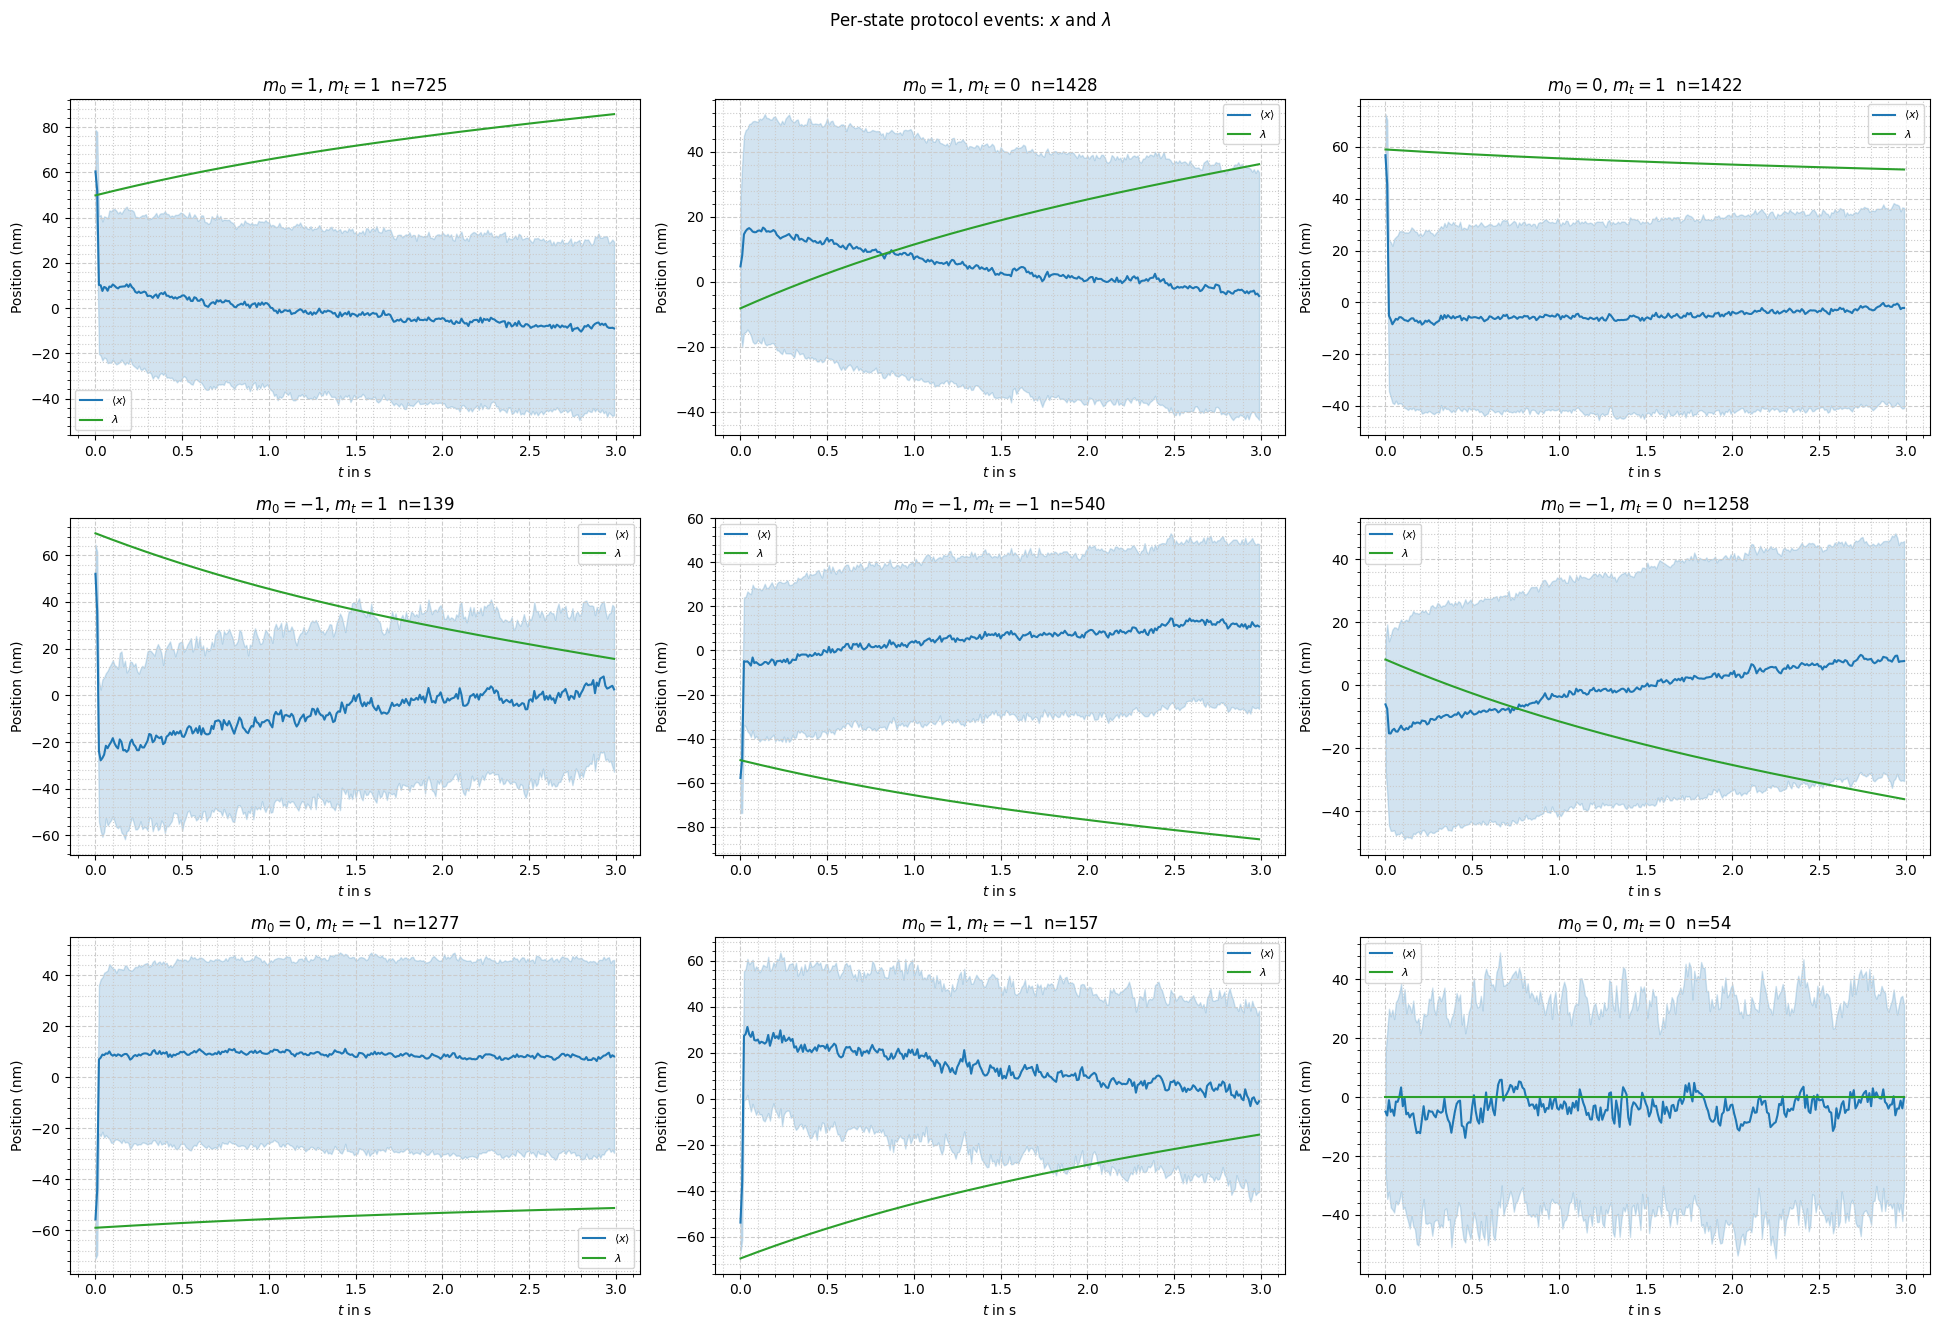

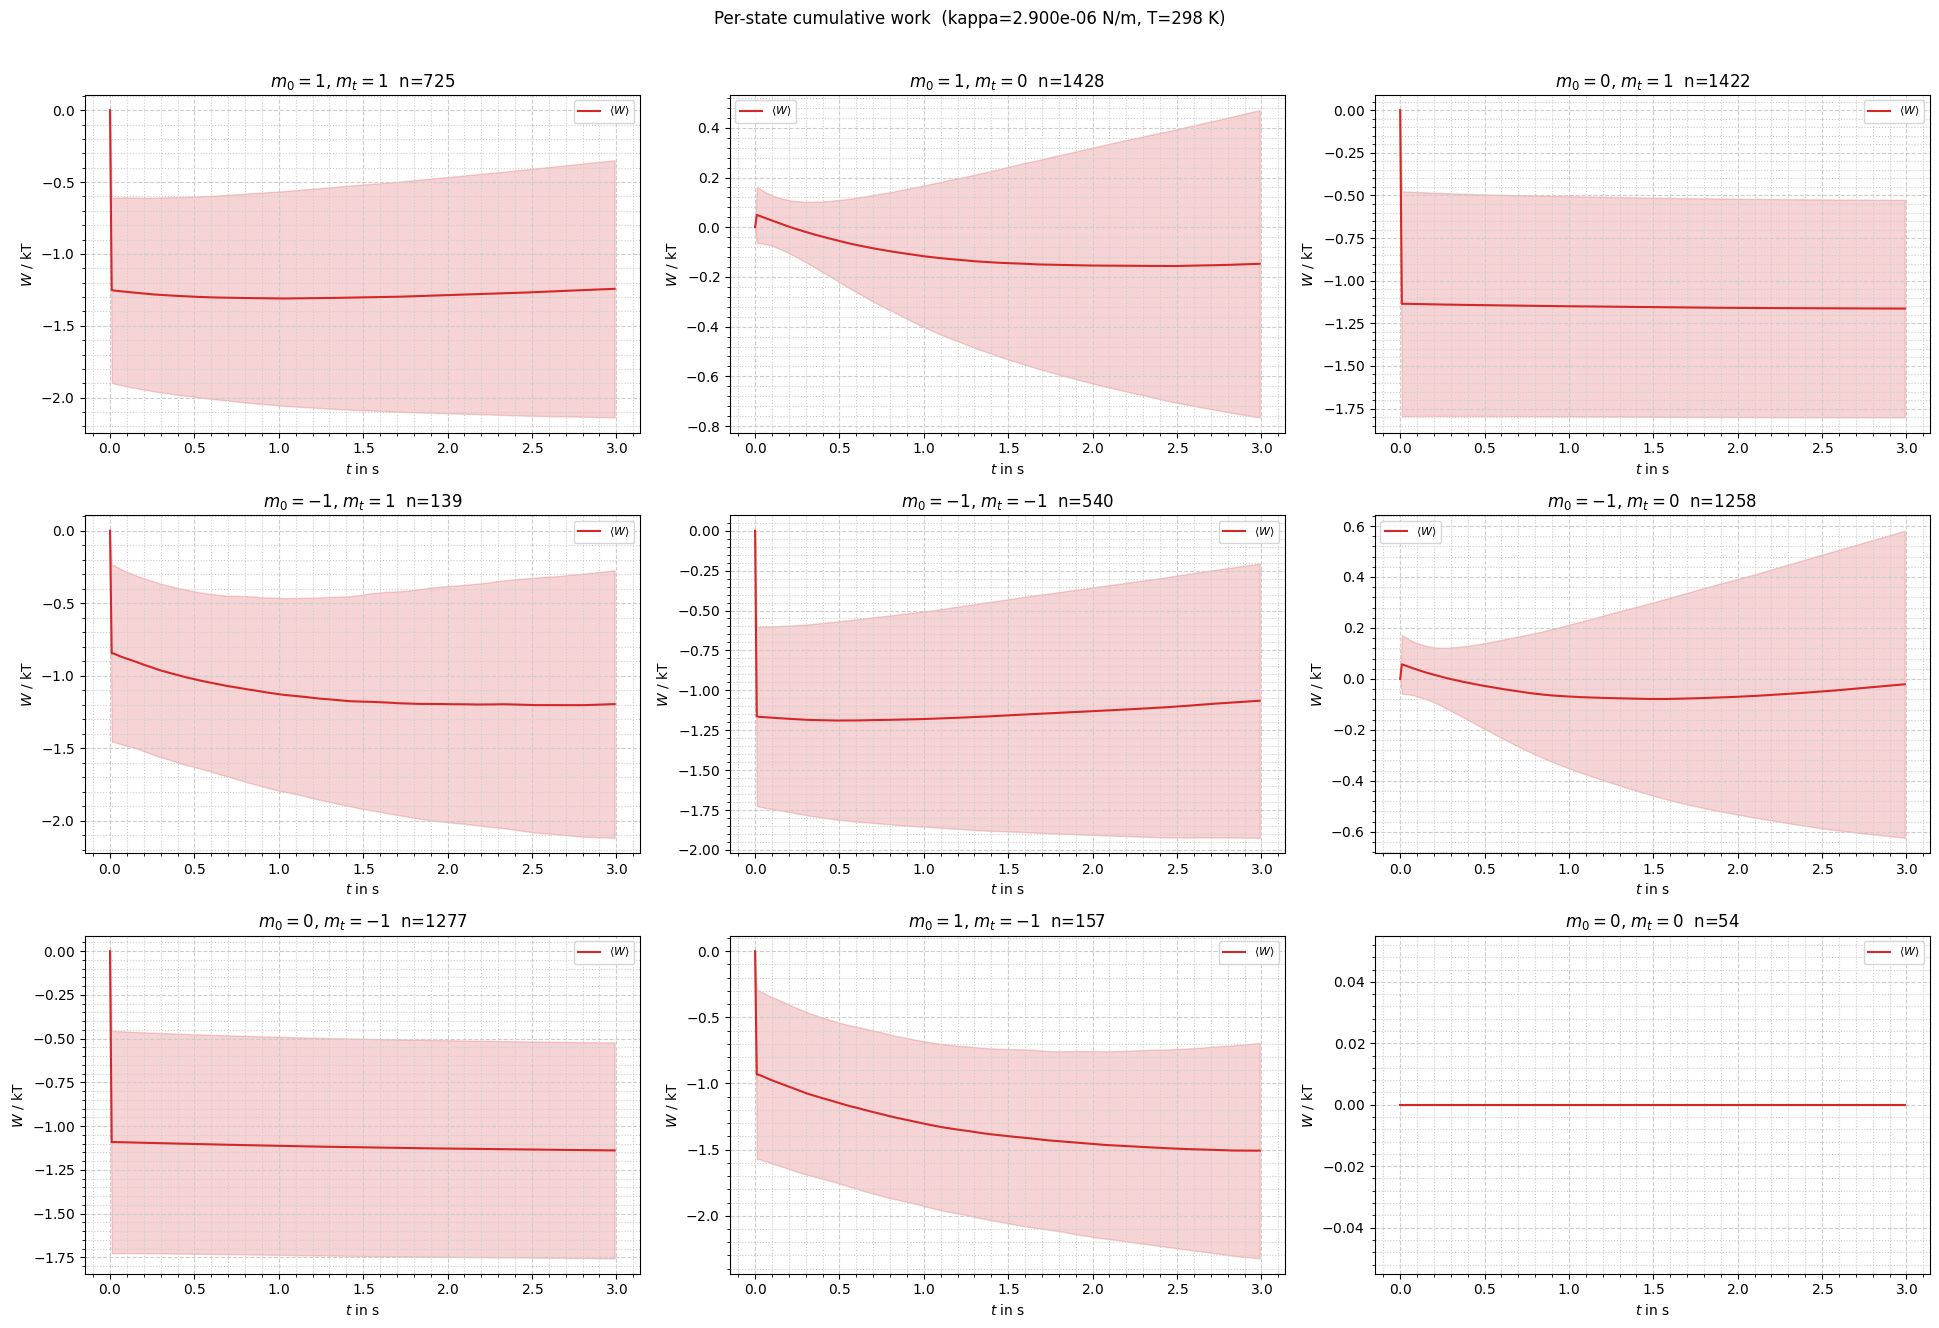

Saved: D:\data\batch06_events_work.mat


In [40]:
BATCH_FOLDER = r"D:\data\batch06" # base_kwargs["savepath"]    from section 6, e.g. r"D:\data\batch01"

batch_events = extract_protocol_events_from_folder(BATCH_FOLDER)
for state, ev in batch_events.items():
    print(f"{state}: {ev['x_nm'].shape[0]} real fired events pooled across the batch "
          f"({ev['x_nm'].shape[1]} samples/event)")

batch_lambdas = {
    state: lambda_trap_nm_for_state(state, batch_events[state]["t_s"], analytical_protocols,
                                    PROTOCOL_DT_S, AO_RATE)
    for state in batch_events
}
batch_works_kT = {
    state: compute_cumulative_work_kT(batch_events[state]["x_nm"], batch_lambdas[state],
                                      ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K)
    for state in batch_events
}
for state in batch_events:
    if batch_events[state]["x_nm"].shape[0]:
        print(f"{state}: mean final work = {batch_works_kT[state][:, -1].mean():+.2f} kT   "
              f"(n={batch_events[state]['x_nm'].shape[0]})")

plot_x_lambda_grid(batch_events, batch_lambdas)
plot_work_grid(batch_events, batch_works_kT, ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K)

export_for_matlab(f"{BATCH_FOLDER}_events_work.mat", batch_events, batch_lambdas, batch_works_kT,
                  ANALYTICAL_KAPPA_N_PER_M, ANALYTICAL_T_K, PROTOCOL_DT_S)


## 7. Confirm the particle is still there

In [ ]:
preview_particle(Cam, fps=100.0)


## 8. Shutdown (optional — only when you're actually powering down)

Ramp `ao1` slowly back to 0V rather than stepping it (a bare voltage step risks losing the particle), then close everything. Left commented out — your call when to actually run it, and it's independent of everything above.

In [ ]:
aom_gen.set_dc_level(AOM_TRANSIT_V)   # strong trap before the shutdown ramp, same as any other transit

current_v = read_stage_voltage()
ao.ramp_ao1(current_v, 0.0, speed_nm_per_s=10.0)

ao.close()
ai.close()
Cam.close()
funcgen.close()
aom_gen.close()


## 9. Standalone diagnostics: tracking latency + protocol-firing latency

Independent of `run_session_2ch`/the real engine — quick to tweak `TEST_ROI`/`TEST_THRES` (or swap `Cam.find()` for a different tracking call entirely) and re-run in seconds, without running a full experiment.

9a tests hardware-trigger frame delivery + `find()` cost against a 5ms/frame target. 9b isolates protocol-firing (`ao.load()`+`ao.start()`) latency against the 10ms frame budget — worth doing given the last real batch run above already showed fire latency sitting right at that line (mean ~8.8ms, max ~11ms).

In [ ]:


# ── 9a. Hardware-trigger frame count + tracking latency ─────────────────────
# Frame count is cross-checked two ways: grab() success count (Python side)
# and CamOut rising edges (hardware ground truth via the DAQ, same method
# build_datasync() uses) — these can disagree even when grab() looks fine,
# since grab() just returns whatever frame is next in the buffer without
# knowing which physical trigger pulse produced it.

TEST_N_FRAMES = 500
TEST_FPS      = 100.0
TEST_ROI      = 96     # find_particle_fast's windowed-search size — tweak & re-run
TEST_THRES    = 80.0   # detection threshold — tweak & re-run

funcgen.setup_camera_trigger(TEST_FPS, 600.0, TEST_N_FRAMES)
Cam.hardwareTrigg()
ai.start_continuous()
time.sleep(0.1)
Cam.start()
ao.hardware_trigger()

frame_dt_ms = int(2000 / TEST_FPS) + 2000
grab_ms, find_ms = [], []
n_dropped = n_lost = 0

for _ in range(TEST_N_FRAMES):
    tg0 = time.perf_counter()
    try:
        frame = Cam.grab(timeout_ms=frame_dt_ms)
    except RuntimeError:
        frame = None
    grab_ms.append((time.perf_counter() - tg0) * 1000)

    if frame is None:
        n_dropped += 1
        continue

    tf0 = time.perf_counter()
    x_nm, y_nm = Cam.find(frame, roi=TEST_ROI, thres=TEST_THRES)
    find_ms.append((time.perf_counter() - tf0) * 1000)
    if np.isnan(x_nm):
        n_lost += 1

Cam.stop()
test_ai_data = ai.stop_and_get()

cam_out = test_ai_data[ai.channel_names.index("CamOut")]
n_confirmed = int(np.sum(np.diff((cam_out > 2.0).astype(np.int8)) > 0))

print(f"Requested: {TEST_N_FRAMES}  |  grab() succeeded: {TEST_N_FRAMES - n_dropped}  "
      f"|  CamOut confirmed (hardware ground truth): {n_confirmed}")
print(f"Dropped (grab failed): {n_dropped}  |  particle not found: {n_lost}\n")

# grab() ~10ms is normal (blocked on the hardware trigger clock); much
# LESS than that means frames were already buffered (loop fell behind).
_stats("grab()", grab_ms)
_stats("find()", find_ms, budget_ms=5.0)


In [ ]:
# ── 9b. Protocol-firing (write+start) latency ────────────────────────────────
# Uses the (0,0) state's waveform — all zeros — so this is physically inert
# (ao0 stays 0, ao1 unchanged: split_channels' last-sample handoff adds 0 to
# the current offset) and safe to repeat without drifting the stage or
# needing a real trigger. Same code path (get_protocol_nm -> split_channels
# -> ao.load -> ao.start) and same array size as a real protocol_dt_s fire,
# so the timing is representative.

from protocols_2ch import get_protocol_nm, split_channels

N_FIRE_TESTS = 5
load_ms, start_ms = [], []
# Read ai3 ("AdderOut"), not ai1 ("Stage") - ai3 is the actual node ao1
# lands on; seeding from ai1 (downstream of the amplifier's own gain/
# offset) would make this NOT physically inert as documented above (see
# section 10's notes for the full explanation).
ao1_probe = read_ai_channel("AdderOut")

for _ in range(N_FIRE_TESTS):
    waveform_nm = get_protocol_nm((0, 0), PROTOCOL_DT_S, AO_RATE)
    ao0_wave, ao1_wave, ao1_probe = split_channels(waveform_nm, ao1_probe)

    t0 = time.perf_counter()
    ao.load(ao0_wave, ao1_wave)
    t1 = time.perf_counter()
    ao.start()
    t2 = time.perf_counter()

    load_ms.append((t1 - t0) * 1000)
    start_ms.append((t2 - t1) * 1000)
    ao.wait_done(extra_s=5.0)

load_arr, start_arr = np.array(load_ms), np.array(start_ms)
total_arr = load_arr + start_arr
print(f"ao.load()  [stop+write]: mean={load_arr.mean():.2f}ms   max={load_arr.max():.2f}ms")
print(f"ao.start() [arm]:        mean={start_arr.mean():.2f}ms   max={start_arr.max():.2f}ms")
print(f"total (load+start):      mean={total_arr.mean():.2f}ms   max={total_arr.max():.2f}ms   "
      f"-> {'under' if total_arr.max() < 10 else 'AT/OVER'} the 10ms frame budget")


## 10. Voltage-to-pixel calibration (Step 1) — one full period, not a one-way ramp

We don't yet know the real voltage→pixel transfer function for either
channel — sign or scale. Every protocol fired so far used placeholder
amplitudes never checked against "does +V actually move the particle where
we think, and by how much." This measures it directly: a slow **sine
wave** on one channel at a time (the other held constant) — one full
period, `0 → +A → 0 → -A → 0` — while the camera tracks the real particle
throughout, giving many `(commanded_v, x_nm)` pairs for a robust linear
fit. A sine (vs. a one-way ramp between two extremes) matters for two
reasons: it starts and ends at 0, matching how a channel actually behaves
during a real protocol (`ao0` is 0 except while firing; a protocol starts
from wherever the stage currently rests and returns to baseline after),
and it sweeps every voltage magnitude twice — once rising, once falling —
so you can also see if there's hysteresis between the two passes.

Alongside the camera, each waveform also records `ai1` ("Stage" — the
amplifier's actual output) and `ai3` ("AdderOut" — the commanded `ao0/10 +
ao1` signal going into the amplifier), both real DAQ recordings compared
directly against each other (not a value predicted from the waveform's
formula) — this isolates the DAQ→adder→amplifier→stage chain from the
optics/camera chain the `x_nm` fit checks. 10c goes further: it fires a
plain ramp through the *exact* real protocol-firing path
(`split_channels` → `ao.load` → `ao.start`) and zooms in tight on the
`ao0→0`/`ao1→new-offset` handoff moment to look for any spike the
amplifier introduces that the commanded signal doesn't have.



In [ ]:
from protocols_2ch import NM_PER_VOLT, V_MIN as STAGE_V_MIN, V_MAX as STAGE_V_MAX

CALIB_FPS   = 100.0
CALIB_ROI   = 96     # find_particle_fast's windowed-search size — tweak & re-run
                     # (own default, not TEST_ROI — this section shouldn't
                     # require section 9 to have been run first)
CALIB_THRES = 80.0   # detection threshold — tweak & re-run

# _wait_for_ai_sample_count / _sine_waveform_v / _track_during_ramp /
# _run_waveform_and_track / _fit_ramp / _plot_ramp / _compare_ai1_ai3 now
# live in helper.py (imported near the top of this notebook) — see that
# file for their docstrings.


### 10a. ao0 (fine channel) sine sweep

One full sine period on ao0 — `0 → +2V → 0 → -2V → 0` — a modest, safe
sub-range of its ±10V span (small relative to the /10 attenuation and the
particle's size), ao1 held at its current resting voltage (read live, not
assumed). `AO0_RAMP_SPEED_NM_S` only paces how slowly the sweep runs (via
the nominal `NM_PER_VOLT/10` attenuated-channel estimate) — it is not
assumed to be the real transfer function, which is exactly what this cell
measures. Runs in a background thread (`daq.py::NICardOutDual.
run_custom_waveform`, new — generalizes `ramp_ao0`/`ramp_ao1` to any
waveform shape) while the main thread tracks the particle continuously.

In [ ]:
AO0_AMPLITUDE_V     = 2.0
AO0_RAMP_SPEED_NM_S = 50.0   # pacing only - see ramp_ao0()/_sine_waveform_v() docstrings

# One full period covers 4x the amplitude in total path length (0->+A->0->-A->0).
ao0_period_s = (4.0 * AO0_AMPLITUDE_V * (NM_PER_VOLT / 10.0)) / AO0_RAMP_SPEED_NM_S
# ao1_hold_v seeds the constant baseline the new waveform holds ao1 at.
# Read ai3 ("AdderOut"), NOT ai1 ("Stage") - ai3 taps the exact node our
# ao0/ao1 commands land on (ao0/10 + ao1); ai1 is downstream of the
# amplifier's own gain/offset, so seeding from it introduces a real step right at task start (ao0=0 here, so ai3 == ao1's effective value).

ao1_hold_v = read_ai_channel("AdderOut")
stage_now_v = read_ai_channel("Stage")

# Pre-flight safety check (test-only): ao0's sine swings +/-AO0_AMPLITUDE_V/10
# around ao1_hold_v (ao1 is held constant the whole test). If the stage was
# never brought up to its real resting ~5V before this cell is run standalone,
# ao1_hold_v can be near 0 - the sine's negative half would then drive the
# combined output (ai3 = ao0/10 + ao1), and so the piezo, negative. Not a
# concern in real experiments (they always start at ~5V) - only matters here
# because this cell can be fired on its own.
predicted_min_v = ao1_hold_v - AO0_AMPLITUDE_V / 10.0
print(f"Pre-flight: ai3(AdderOut)={ao1_hold_v:.4f}V  ai1(Stage)={stage_now_v:.4f}V  "
      f"predicted ai3 minimum during sweep = {predicted_min_v:.4f}V")

if predicted_min_v < 0:
    safe_ao1_v = (AO0_AMPLITUDE_V + 1.0) / 10.0   # leaves 0.1V of margin above 0
    print(f"WARNING: sweep would drive the piezo negative ({predicted_min_v:.4f}V) "
          f"- ramping ao1 to a safe {safe_ao1_v:.4f} V first ...")
    ao.ramp_ao1(ao1_hold_v, safe_ao1_v, AO0_RAMP_SPEED_NM_S)
    ao1_hold_v = safe_ao1_v

print(f"ao0: one period, 0 -> +{AO0_AMPLITUDE_V}V -> 0 -> -{AO0_AMPLITUDE_V}V -> 0, "
      f"over {ao0_period_s:.1f}s   (ao1 held at current commanded voltage: {ao1_hold_v:.4f} V)")

_, ao0_wave_sine = _sine_waveform_v(AO0_AMPLITUDE_V, ao0_period_s, AO_RATE)
ao1_wave_sine = np.full(len(ao0_wave_sine), ao1_hold_v, dtype=np.float64)

ao0_t_rel, ao0_x_nm, ai_idx0, ao0_ai_data = _run_waveform_and_track(
    Cam, funcgen, ao, ai, ao0_wave_sine, ao1_wave_sine,
    CALIB_FPS, 600.0, ao0_period_s, CALIB_ROI, CALIB_THRES
)

ao0_commanded_v = AO0_AMPLITUDE_V * np.sin(2 * np.pi * np.clip(ao0_t_rel, 0, ao0_period_s) / ao0_period_s)

slope_ao0, intercept_ao0, r2_ao0, valid_ao0 = _fit_ramp(ao0_commanded_v, ao0_x_nm)
print(f"ao0 -> x: slope = {slope_ao0:+.2f} nm/V   intercept = {intercept_ao0:+.2f} nm   R^2 = {r2_ao0:.4f}")

_plot_ramp(ao0_t_rel, ao0_commanded_v, ao0_x_nm, valid_ao0, slope_ao0, intercept_ao0, r2_ao0,
          -AO0_AMPLITUDE_V, AO0_AMPLITUDE_V, "ao0", "tab:blue")

# Direct real-vs-real check: ai3 (commanded, into the amp) vs. ai1 (the
# amp's actual output) - no assumption about the waveform's shape needed.
_compare_ai1_ai3(ao0_ai_data, ai.channel_names, ai_idx0, ai.rate, ao0_period_s, "ao0 sine")


### 10b. ao1 (coarse channel) sine sweep

Same idea, on ao1: one full sine period centered on its current resting
voltage, amplitude auto-clamped to stay well inside
`stage_min_v`/`stage_max_v` no matter where it currently rests, ao0 held
at 0 throughout. Uses the real `NM_PER_VOLT` pacing convention already
used elsewhere (`ensure_stage_at`'s default 10 nm/s) — also under test
here, since this cell is what confirms or corrects it. Being a closed
loop, it needs no separate "return to start" step — it already ends back
where it began.

In [ ]:
AO1_AMPLITUDE_V     = 0.5   # +/- around the current resting voltage
AO1_RAMP_SPEED_NM_S = 10.0  # same convention as ensure_stage_at's default

# Read ai3 ("AdderOut"), NOT ai1 ("Stage") - see 10a's note: ai3 is the
# same electrical node our ao1 command lands on, ai1 is downstream of the
# amplifier's own gain/offset and would seed a real step at task start.
ao1_center_v  = read_ai_channel("AdderOut")
ao1_amplitude_v = min(AO1_AMPLITUDE_V, ao1_center_v - STAGE_V_MIN, STAGE_V_MAX - ao1_center_v)
ao1_period_s  = (4.0 * ao1_amplitude_v * NM_PER_VOLT) / AO1_RAMP_SPEED_NM_S
print(f"ao1: one period, {ao1_center_v:.3f}V -> +{ao1_amplitude_v:.3f}V -> {ao1_center_v:.3f}V -> "
      f"-{ao1_amplitude_v:.3f}V -> {ao1_center_v:.3f}V, over {ao1_period_s:.1f}s")

_, ao1_wave_offset = _sine_waveform_v(ao1_amplitude_v, ao1_period_s, AO_RATE)
ao1_wave_sine = ao1_center_v + ao1_wave_offset
ao0_wave_sine = np.zeros(len(ao1_wave_sine), dtype=np.float64)

ao1_t_rel, ao1_x_nm, ai_idx0, ao1_ai_data = _run_waveform_and_track(
    Cam, funcgen, ao, ai, ao0_wave_sine, ao1_wave_sine,
    CALIB_FPS, 600.0, ao1_period_s, CALIB_ROI, CALIB_THRES
)

ao1_commanded_v = ao1_center_v + ao1_amplitude_v * \
    np.sin(2 * np.pi * np.clip(ao1_t_rel, 0, ao1_period_s) / ao1_period_s)

slope_ao1, intercept_ao1, r2_ao1, valid_ao1 = _fit_ramp(ao1_commanded_v, ao1_x_nm)
print(f"ao1 -> x: slope = {slope_ao1:+.2f} nm/V   intercept = {intercept_ao1:+.2f} nm   R^2 = {r2_ao1:.4f}   "
      f"(assumed NM_PER_VOLT = {NM_PER_VOLT:.0f} nm/V)")

_plot_ramp(ao1_t_rel, ao1_commanded_v, ao1_x_nm, valid_ao1, slope_ao1, intercept_ao1, r2_ao1,
          ao1_center_v - ao1_amplitude_v, ao1_center_v + ao1_amplitude_v, "ao1", "tab:orange")

# Direct real-vs-real check: ai3 (commanded, into the amp) vs. ai1 (the
# amp's actual output) - no assumption about the waveform's shape needed.
_compare_ai1_ai3(ao1_ai_data, ai.channel_names, ai_idx0, ai.rate, ao1_period_s, "ao1 sine")


### 10c. Protocol handoff check: ao0 excursion → snap to 0, ao1 absorbs the offset

Exercises the *exact* real firing path a session uses — `split_channels()`
→ `ao.load()` → `ao.start()`, same array length as a real `protocol_dt_s`
fire — with a plain 0→2V linear ramp standing in for a real (still-
placeholder) protocol shape, so the only thing under test is the
last-sample handoff itself: `ao0` snaps to 0 while `ao1` simultaneously
jumps to absorb the net displacement, on the same sample clock. Zooms
`_compare_ai1_ai3` in tight around that instant to look for any spike or
glitch in the real amplifier output (`ai1`) that the commanded signal
(`ai3`) doesn't show.

In [ ]:
from protocols_2ch import split_channels

HANDOFF_AO0_PEAK_V = 2.0   # ao0 volts reached just before the handoff

# A plain linear ramp in nm-displacement terms - split_channels() works on
# any nm waveform, not just the placeholder BASE_PROTOCOLS shapes, so this
# tests the handoff mechanic on its own with a known, clean input.
handoff_waveform_nm = np.linspace(
    0.0, HANDOFF_AO0_PEAK_V / 10.0 * NM_PER_VOLT, int(PROTOCOL_DT_S * AO_RATE)
)

# Read ai3 ("AdderOut"), NOT ai1 ("Stage") - ai3 is the same electrical
# node our ao0/ao1 commands land on (ao0/10 + ao1); ai1 is downstream of
# the amplifier's own gain/offset, so seeding split_channels()'s baseline
# from it introduces a real step right when the new task starts (ao0=0
# here, so ai3 == ao1's effective value).
ao1_before = read_ai_channel("AdderOut")
handoff_ao0_wave, handoff_ao1_wave, ao1_after = split_channels(handoff_waveform_nm, ao1_before)
print(f"ao0: 0V -> {handoff_ao0_wave[-2]:.3f}V -> 0V (handoff)   "
      f"ao1: {ao1_before:.4f}V -> {ao1_after:.4f}V")

ai.start_continuous()
_wait_for_ai_sample_count(ai)   # see its docstring - a fixed short sleep
                                # here reads a stale/zero sample count and
                                # mislabels the whole plot's time axis
ai_idx0 = ai.get_sample_count()
try:
    ao.load(handoff_ao0_wave, handoff_ao1_wave)
    ao.start()
    ao.wait_done(extra_s=5.0)
finally:
    # Guarantees the AI task is released even if wait_done() times out or
    # anything above raises - otherwise ai1 stays reserved by this cell's
    # background thread and the next hardware call anywhere in the
    # notebook (e.g. ensure_stage_at) fails with a device-busy error.
    handoff_ai_data = ai.stop_and_get()

_compare_ai1_ai3(handoff_ai_data, ai.channel_names, ai_idx0, ai.rate, PROTOCOL_DT_S,
                 "protocol handoff", margin_s=1.0, show_nm=True,
                 zoom_center_s=PROTOCOL_DT_S, zoom_window_s=0.1)
ensure_stage_at(ao, V_CENTER, speed_nm_per_s=200.0, camera=Cam, live_preview=True, settle_s = 0.5)
